In [79]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from sklearn.model_selection import train_test_split
from torch_geometric.nn import GCNConv, GATConv, GINConv
import pandas as pd
import json
import matplotlib.pyplot as plt
from torch_geometric.data import Data
import os

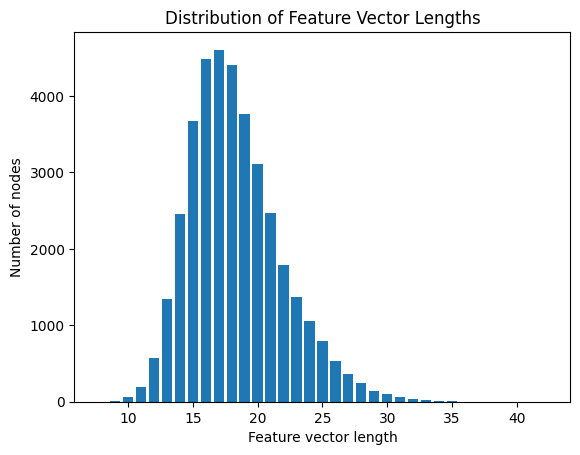

In [80]:
file_path = os.path.join("..", "features.json")

with open(file_path, "r") as f:
    features_dict = json.load(f)

count = {}
for key, value in features_dict.items():
    k = len(value)
    count[k] = count.get(k, 0) + 1

x = sorted(count.keys())
y = [count[k] for k in x]

#plot the distribution of feature vector lengths
plt.figure()
plt.bar(x, y)
plt.xlabel("Feature vector length")
plt.ylabel("Number of nodes")
plt.title("Distribution of Feature Vector Lengths")
plt.show()



### Pad and clip:
- pad the feature vectors which are less than the mode of the distribution
- clip the feature vectors which are more than the mode of the distribution

In [81]:
L_mode = max(count, key=count.get)     #mode of the distribution

def pad_clip(v, L):
    if len(v) >= L:
        return v[:L]
    return v + [0.0] * (L - len(v))


In [82]:
N = len(features_dict)          # no. of nodes

x = torch.tensor(
    [pad_clip(features_dict[str(i)], L_mode) for i in range(N)],
    dtype=torch.float
)


In [83]:
edges_path = os.path.join("..", "edges.csv")

edges_df = pd.read_csv(edges_path)

edge_index = torch.tensor(
    edges_df[["id_1", "id_2"]].values.T,
    dtype=torch.long
)
edge_index = torch.cat(
    [edge_index, edge_index.flip(0)],
    dim=1
)

In [84]:
target_path = os.path.join("..", "target.csv")

target_df = pd.read_csv(target_path)

y = torch.tensor(
    target_df["ml_target"].values,
    dtype=torch.long
)

In [85]:
num_nodes = y.size(0)
idx = torch.arange(num_nodes)

train_idx, temp_idx = train_test_split(
    idx,
    train_size=0.7,
    stratify=y
)

val_idx, test_idx = train_test_split(
    temp_idx,
    train_size=0.5,
    stratify=y[temp_idx]
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True


In [86]:
#Normalize
mean = x[train_mask].mean(dim=0)
std = x[train_mask].std(dim=0)

# Apply to all (or handle separately)
x = (x - mean) / (std + 1e-8)

In [87]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x = x.to(device)
y = y.to(device)
edge_index = edge_index.to(device)

In [116]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, x, edge_index, mask, y):
    model.eval()
    with torch.no_grad():
        out = model(x, edge_index)
        pred = out.argmax(dim=1)
        
        cm = confusion_matrix(y[mask].cpu(), pred[mask].cpu())
        
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

from sklearn.metrics import f1_score, roc_auc_score

def eval_metrics(model, x, edge_index, mask, y):
    model.eval()
    with torch.no_grad():
        out = model(x, edge_index)
        pred = out.argmax(dim=1)
        prob = torch.softmax(out, dim=1)[:, 1] # Probability of positive class for ROC-AUC
        
        # Convert to CPU for sklearn
        y_true = y[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()
        y_prob = prob[mask].cpu().numpy()
        
        f1 = f1_score(y_true, y_pred, average='macro')
        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = 0.0 # Handle cases where only one class is present in batch
            
    return f1, auc

### GCN:

In [117]:
class PyG_GCN(nn.Module):
    def __init__(self, F_in, F_hidden, F_out, want_proj = True, F_proj = 64):
        super().__init__()
        self.want_proj = want_proj
        if self.want_proj: 
            self.proj = nn.Linear(F_in, F_proj)
        else: 
            F_proj = F_in
        self.conv1 = GCNConv(F_proj, F_hidden, cached=True, normalize=True)
        self.conv2 = GCNConv(F_hidden, F_out, cached=True, normalize=True)
        self.dropout = nn.Dropout(p=0.5)
    
    def forward(self, x, edge_index):
        if self.want_proj:
            x = F.relu(self.proj(x)) 
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

In [118]:
lr = 0.005
wd = 1e-3
epochs = 350

In [119]:
def train_and_eval(model, x, edge_index, train_mask, val_mask, epochs, lr, wd):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out = model(x, edge_index)
        loss = loss_fn(out[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                out = model(x, edge_index)
                pred = out.argmax(dim=1)
                val_acc = (
                    pred[val_mask] == y[val_mask]
                ).float().mean()
            f1, auc = eval_metrics(model, x, edge_index, val_mask, y)
            print(f"Epoch {epoch:03d} | Loss {loss:.4f} | Val Acc {val_acc:.4f} | F1 {f1:4f}")


In [120]:
model = PyG_GCN(
    F_in=x.size(1),
    F_hidden=16,
    F_out=2
).to(device)
train_and_eval(model, x, edge_index, train_mask, val_mask, epochs, lr, wd)

Epoch 000 | Loss 0.7037 | Val Acc 0.7447 | F1 0.615788
Epoch 020 | Loss 0.5560 | Val Acc 0.7413 | F1 0.426381
Epoch 040 | Loss 0.5270 | Val Acc 0.7618 | F1 0.552794
Epoch 060 | Loss 0.5003 | Val Acc 0.7837 | F1 0.640960
Epoch 080 | Loss 0.4922 | Val Acc 0.7857 | F1 0.640312
Epoch 100 | Loss 0.4839 | Val Acc 0.7966 | F1 0.674395
Epoch 120 | Loss 0.4784 | Val Acc 0.7963 | F1 0.665867
Epoch 140 | Loss 0.4673 | Val Acc 0.7972 | F1 0.667919
Epoch 160 | Loss 0.4772 | Val Acc 0.7988 | F1 0.669449
Epoch 180 | Loss 0.4682 | Val Acc 0.8014 | F1 0.676963
Epoch 200 | Loss 0.4660 | Val Acc 0.7986 | F1 0.665620
Epoch 220 | Loss 0.4614 | Val Acc 0.7996 | F1 0.668607
Epoch 240 | Loss 0.4654 | Val Acc 0.8032 | F1 0.681429
Epoch 260 | Loss 0.4635 | Val Acc 0.8032 | F1 0.680068
Epoch 280 | Loss 0.4558 | Val Acc 0.8080 | F1 0.696495
Epoch 300 | Loss 0.4624 | Val Acc 0.8085 | F1 0.693895
Epoch 320 | Loss 0.4546 | Val Acc 0.8087 | F1 0.696790
Epoch 340 | Loss 0.4572 | Val Acc 0.8073 | F1 0.692448


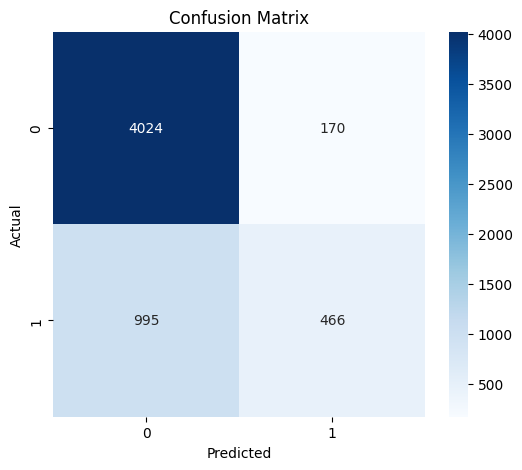

In [121]:
plot_confusion_matrix(model, x, edge_index, test_mask, y)

### GAT:

In [122]:
class PyG_GAT(nn.Module):
    def __init__(self, F_in, F_hidden, F_out, heads = 8, want_proj = True, F_proj = 64):
        super().__init__()
        self.want_proj = want_proj
        if self.want_proj: 
            self.proj = nn.Linear(F_in, F_proj)
        else: 
            F_proj = F_in
        self.gat1 = GATConv(F_proj, F_hidden, heads=heads, concat=True)
        self.gat2 = GATConv(F_hidden*heads, F_out, heads=1, concat=False)
        self.dropout = nn.Dropout(p=0.5)
    
    def forward(self, x, edge_index):
        if self.want_proj:
            x = F.relu(self.proj(x))
        x = F.elu(self.gat1(x, edge_index))
        x = self.dropout(x)
        x = self.gat2(x, edge_index)
        return x
        

In [123]:
model = PyG_GAT(
    F_in=x.size(1),
    F_hidden=8,
    F_out=2,
    heads=8
).to(device)

train_and_eval(model, x, edge_index, train_mask, val_mask, epochs, lr, wd)


Epoch 000 | Loss 0.6075 | Val Acc 0.7416 | F1 0.425830
Epoch 020 | Loss 0.5093 | Val Acc 0.7788 | F1 0.603150
Epoch 040 | Loss 0.4801 | Val Acc 0.7950 | F1 0.655390
Epoch 060 | Loss 0.4588 | Val Acc 0.8064 | F1 0.686136
Epoch 080 | Loss 0.4425 | Val Acc 0.8202 | F1 0.722924
Epoch 100 | Loss 0.4351 | Val Acc 0.8278 | F1 0.743051
Epoch 120 | Loss 0.4266 | Val Acc 0.8191 | F1 0.708220
Epoch 140 | Loss 0.4212 | Val Acc 0.8317 | F1 0.747474
Epoch 160 | Loss 0.4184 | Val Acc 0.8318 | F1 0.747662
Epoch 180 | Loss 0.4180 | Val Acc 0.8352 | F1 0.759878
Epoch 200 | Loss 0.4134 | Val Acc 0.8373 | F1 0.766577
Epoch 220 | Loss 0.4179 | Val Acc 0.8368 | F1 0.759899
Epoch 240 | Loss 0.4122 | Val Acc 0.8343 | F1 0.751376
Epoch 260 | Loss 0.4146 | Val Acc 0.8382 | F1 0.763369
Epoch 280 | Loss 0.4077 | Val Acc 0.8350 | F1 0.751061
Epoch 300 | Loss 0.4083 | Val Acc 0.8366 | F1 0.755797
Epoch 320 | Loss 0.4092 | Val Acc 0.8385 | F1 0.763058
Epoch 340 | Loss 0.4078 | Val Acc 0.8391 | F1 0.764043


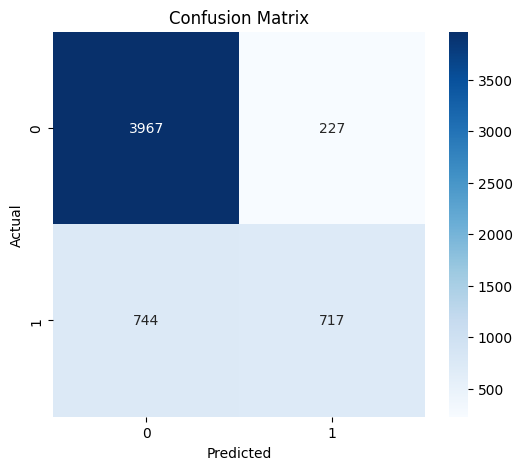

In [124]:
plot_confusion_matrix(model, x, edge_index, test_mask, y)

### GIN:

In [125]:
class PyG_GIN(nn.Module):
    def __init__(self, F_in, F_hidden, F_out, want_proj = True, F_proj = 64):
        super().__init__()

        self.want_proj = want_proj
        if self.want_proj: 
            self.proj = nn.Linear(F_in, F_proj)
        else: 
            F_proj = F_in

        mlp1 = nn.Sequential(
            nn.Linear(F_proj, F_hidden),
            nn.BatchNorm1d(F_hidden),
            nn.ReLU(),
            nn.Linear(F_hidden, F_hidden),
            nn.BatchNorm1d(F_hidden),
            nn.ReLU()
        )

        mlp2 = nn.Sequential(
            nn.Linear(F_hidden, F_hidden),
            nn.BatchNorm1d(F_hidden),
            nn.ReLU(),
            nn.Linear(F_hidden, F_out),
            nn.BatchNorm1d(F_out),
            nn.ReLU(),
        )

        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)

    def forward(self, x, edge_index):
        if self.want_proj :
            x = F.relu(self.proj(x))
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

In [126]:
model = PyG_GIN(
    F_in=x.size(1),
    F_hidden=64,
    F_out=2
).to(device)

train_and_eval(model, x, edge_index, train_mask, val_mask, epochs, lr, wd)

Epoch 000 | Loss 0.7167 | Val Acc 0.7416 | F1 0.425830
Epoch 020 | Loss 0.5616 | Val Acc 0.6087 | F1 0.575801
Epoch 040 | Loss 0.5318 | Val Acc 0.6881 | F1 0.640816
Epoch 060 | Loss 0.5115 | Val Acc 0.7910 | F1 0.718670
Epoch 080 | Loss 0.5042 | Val Acc 0.7708 | F1 0.657897
Epoch 100 | Loss 0.4885 | Val Acc 0.7715 | F1 0.714974
Epoch 120 | Loss 0.4800 | Val Acc 0.7719 | F1 0.668977
Epoch 140 | Loss 0.4596 | Val Acc 0.5356 | F1 0.522581
Epoch 160 | Loss 0.4415 | Val Acc 0.7455 | F1 0.692636
Epoch 180 | Loss 0.4500 | Val Acc 0.7347 | F1 0.669864
Epoch 200 | Loss 0.4238 | Val Acc 0.8180 | F1 0.715400
Epoch 220 | Loss 0.4204 | Val Acc 0.7761 | F1 0.559213
Epoch 240 | Loss 0.4085 | Val Acc 0.7754 | F1 0.704052
Epoch 260 | Loss 0.4088 | Val Acc 0.8124 | F1 0.706938
Epoch 280 | Loss 0.4025 | Val Acc 0.6916 | F1 0.635830
Epoch 300 | Loss 0.4235 | Val Acc 0.8118 | F1 0.673252
Epoch 320 | Loss 0.3897 | Val Acc 0.8294 | F1 0.729116
Epoch 340 | Loss 0.3846 | Val Acc 0.8359 | F1 0.749981


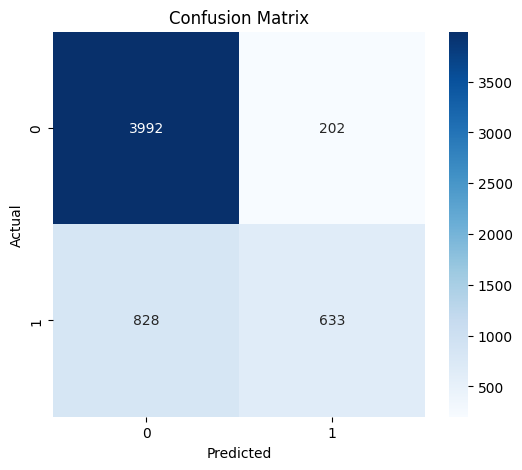

In [127]:
plot_confusion_matrix(model, x, edge_index, test_mask, y)

### Using statistical aggregation

In [128]:
def aggregate(v):
    v = np.asarray(v, dtype=np.float32)

    if len(v) == 0:
        return [0.0, 0.0, 0.0, 0.0, 0.0]

    return [
        float(v.mean()),
        float(v.std()) if len(v) > 1 else 0.0,
        float(v.min()),
        float(v.max()),
        float(len(v))
    ]

In [129]:
x = torch.tensor(
    [aggregate(features_dict[str(i)]) for i in range(len(features_dict))],
    dtype=torch.float
)

x = (x - x.mean(dim=0)) / (x.std(dim=0) + 1e-8)
x = x.to(device)

### GCN:

In [130]:
model = PyG_GCN(
    F_in=x.size(1),
    F_hidden=16,
    F_out=2,
    want_proj=False  # using only the statistically aggregated feature vector
).to(device)
train_and_eval(model, x, edge_index, train_mask, val_mask, epochs, lr, wd)

Epoch 000 | Loss 0.7361 | Val Acc 0.3807 | F1 0.380223
Epoch 020 | Loss 0.5961 | Val Acc 0.7439 | F1 0.441638
Epoch 040 | Loss 0.5546 | Val Acc 0.7464 | F1 0.452002
Epoch 060 | Loss 0.5297 | Val Acc 0.7687 | F1 0.556633
Epoch 080 | Loss 0.5147 | Val Acc 0.7763 | F1 0.601727
Epoch 100 | Loss 0.5114 | Val Acc 0.7774 | F1 0.613523
Epoch 120 | Loss 0.5052 | Val Acc 0.7795 | F1 0.623199
Epoch 140 | Loss 0.5058 | Val Acc 0.7811 | F1 0.626644
Epoch 160 | Loss 0.5022 | Val Acc 0.7798 | F1 0.623803
Epoch 180 | Loss 0.4998 | Val Acc 0.7809 | F1 0.626777
Epoch 200 | Loss 0.5008 | Val Acc 0.7802 | F1 0.624115
Epoch 220 | Loss 0.4988 | Val Acc 0.7798 | F1 0.624096
Epoch 240 | Loss 0.4980 | Val Acc 0.7811 | F1 0.626644
Epoch 260 | Loss 0.4991 | Val Acc 0.7804 | F1 0.624855
Epoch 280 | Loss 0.4967 | Val Acc 0.7800 | F1 0.623666
Epoch 300 | Loss 0.4981 | Val Acc 0.7798 | F1 0.624096
Epoch 320 | Loss 0.4947 | Val Acc 0.7797 | F1 0.623647
Epoch 340 | Loss 0.4945 | Val Acc 0.7805 | F1 0.625885


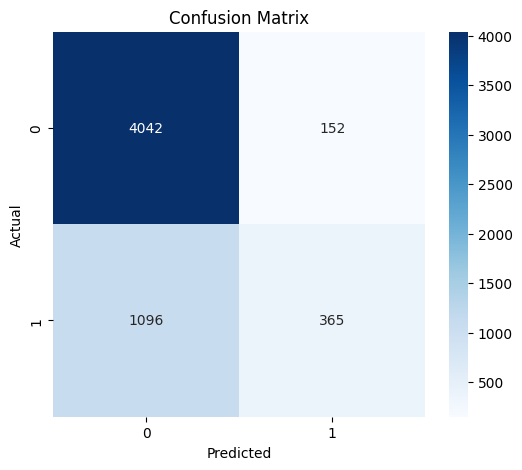

In [131]:
plot_confusion_matrix(model, x, edge_index, test_mask, y)

### GAT:

In [132]:
model = PyG_GAT(
    F_in=x.size(1),
    F_hidden=16,
    F_out=2,
    want_proj=False
).to(device)
train_and_eval(model, x, edge_index, train_mask, val_mask, epochs, lr, wd)

Epoch 000 | Loss 0.6907 | Val Acc 0.7660 | F1 0.632618
Epoch 020 | Loss 0.5193 | Val Acc 0.7798 | F1 0.591099
Epoch 040 | Loss 0.4908 | Val Acc 0.7890 | F1 0.619943
Epoch 060 | Loss 0.4712 | Val Acc 0.8081 | F1 0.691404
Epoch 080 | Loss 0.4529 | Val Acc 0.8108 | F1 0.701975
Epoch 100 | Loss 0.4424 | Val Acc 0.8145 | F1 0.710636
Epoch 120 | Loss 0.4453 | Val Acc 0.8189 | F1 0.732759
Epoch 140 | Loss 0.4447 | Val Acc 0.8156 | F1 0.719794
Epoch 160 | Loss 0.4402 | Val Acc 0.8182 | F1 0.730110
Epoch 180 | Loss 0.4351 | Val Acc 0.8187 | F1 0.723235
Epoch 200 | Loss 0.4369 | Val Acc 0.8177 | F1 0.720371
Epoch 220 | Loss 0.4355 | Val Acc 0.8193 | F1 0.727904
Epoch 240 | Loss 0.4361 | Val Acc 0.8193 | F1 0.724656
Epoch 260 | Loss 0.4295 | Val Acc 0.8186 | F1 0.722525
Epoch 280 | Loss 0.4297 | Val Acc 0.8207 | F1 0.729028
Epoch 300 | Loss 0.4312 | Val Acc 0.8225 | F1 0.736411
Epoch 320 | Loss 0.4311 | Val Acc 0.8232 | F1 0.739022
Epoch 340 | Loss 0.4292 | Val Acc 0.8207 | F1 0.728521


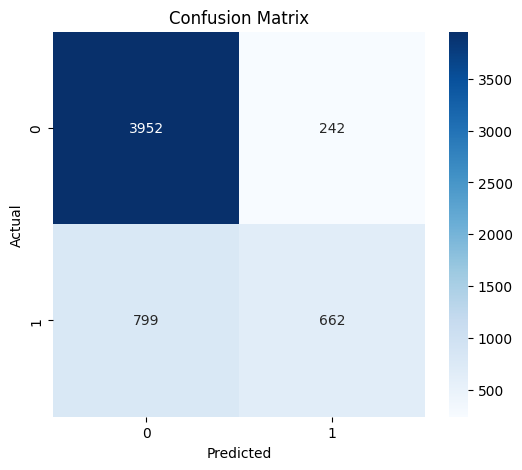

In [133]:
plot_confusion_matrix(model, x, edge_index, test_mask, y)

### GIN:

In [134]:
model = PyG_GIN(
    F_in=x.size(1),
    F_hidden=16,
    F_out=2,
    want_proj=False
).to(device)
train_and_eval(model, x, edge_index, train_mask, val_mask, epochs, lr, wd)

Epoch 000 | Loss 0.7787 | Val Acc 0.6317 | F1 0.558492
Epoch 020 | Loss 0.5616 | Val Acc 0.7802 | F1 0.585817
Epoch 040 | Loss 0.5232 | Val Acc 0.8058 | F1 0.681761
Epoch 060 | Loss 0.4978 | Val Acc 0.8195 | F1 0.725013
Epoch 080 | Loss 0.4775 | Val Acc 0.7871 | F1 0.731289
Epoch 100 | Loss 0.4583 | Val Acc 0.8150 | F1 0.740612
Epoch 120 | Loss 0.4399 | Val Acc 0.8154 | F1 0.749077
Epoch 140 | Loss 0.4282 | Val Acc 0.8212 | F1 0.746650
Epoch 160 | Loss 0.4162 | Val Acc 0.8154 | F1 0.750671
Epoch 180 | Loss 0.4075 | Val Acc 0.8219 | F1 0.763100
Epoch 200 | Loss 0.4020 | Val Acc 0.8242 | F1 0.757337
Epoch 220 | Loss 0.3967 | Val Acc 0.8256 | F1 0.754969
Epoch 240 | Loss 0.3961 | Val Acc 0.8279 | F1 0.754429
Epoch 260 | Loss 0.3900 | Val Acc 0.8265 | F1 0.757310
Epoch 280 | Loss 0.3868 | Val Acc 0.8294 | F1 0.755908
Epoch 300 | Loss 0.3862 | Val Acc 0.8301 | F1 0.757858
Epoch 320 | Loss 0.3934 | Val Acc 0.8253 | F1 0.758056
Epoch 340 | Loss 0.3880 | Val Acc 0.8304 | F1 0.757694


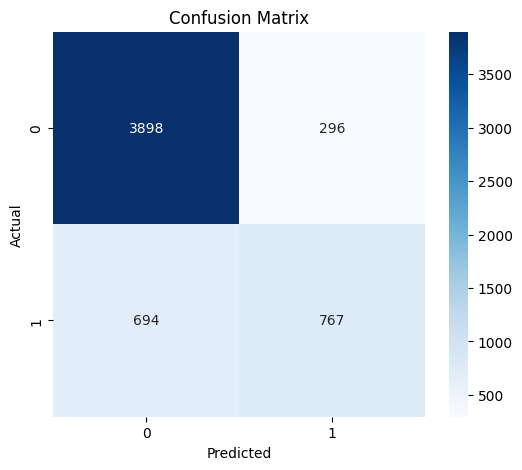

In [135]:
plot_confusion_matrix(model, x, edge_index, test_mask, y)